# Convergent Probe CBED — Au [100]

Thickness-resolved high-angle CBED comparison for Au [100].

- **Reference method**: Wave Propagation Method (WP-MS)
- **Test methods**: Fresnel multislice and Angular Spectrum multislice
- **Probe angles**: configurable
- **Thickness**: repeated Au [100] unit cells up to approximately 100 nm
- **Z-sampling**: configured below
- **Stored outputs**: per-unit-cell errors vs WP-MS, per-unit-cell timings, and final CBED patterns for later plotting

In [1]:
%matplotlib inline

import os
import sys
from pathlib import Path
from time import perf_counter

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", ".7")


def _repo_root_from_notebook():
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        if (base / "notebooks").exists() and (base / "wide_angle_propagation").exists():
            return base
    return cwd


REPO_ROOT = _repo_root_from_notebook()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})
from ase.build import bulk
from matplotlib.colors import LogNorm

from wide_angle_propagation.notebook_utils import (
    angle_crop_slices,
    assert_scattering_support,
    cbed_amplitude,
    diffraction_angle_axes_mrad,
    diffraction_pattern_numpy,
    make_kirkland_probe,
    method_key,
    relative_rmse,
    resolve_repo_root,
    simulate_fresnel_as_exit_only,
    simulate_wpm_exit_only,
)
from wide_angle_propagation.propagation_methods import (
    angular_spectrum_propagation_kernel,
    energy2wavelength,
    fresnel_propagation_kernel,
    simulate_fresnel_as,
    simulate_wpm,
)

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)


## Experiment setup



The simulation uses one Au [100] unit cell potential and repeats it until the cumulative thickness reaches approximately 100 nm. Results are recorded after each unit cell.

In [2]:
# --- Experiment parameters ---
energy = 200e3
a_Au = 4.08
TARGET_THICKNESS_NM = 100.0
PROBE_ANGLES_MRAD = np.array([5.0], dtype=float)

# Test-method grid and z-sampling.
TEST_GPTS = (2048, 2048)
TEST_SLICES_PER_CELL = 64

# Lateral supercell: repeat the Au [100] cubic unit cell NX_REP × NY_REP times.
NX_REP = 9
NY_REP = 9

RUN_WPM = True
WPM_N_BINS = 64
SAVE_RESULTS_NPZ = True
LOAD_EXISTING_RESULTS = False
RECOMPUTE_SIMULATION = True
RESULTS_FILENAME = "exploratory_cbed_thickness_series_au100_100nm.npz"

CENTRAL_ZOOM_OUTER_FRACTION = 1.25
# Single cutoff used for all CBED image panels (same angular window everywhere).
CENTRAL_VIEW_CUTOFF_MRAD = 50.0

# --- Build Au [100] cubic unit cell ---
unit_cell = bulk("Au", "fcc", a=a_Au, cubic=True)
unit_cell.pbc = [True, True, True]

z_period = a_Au
nx_rep = NX_REP
ny_rep = NY_REP
n_unit_cells = int(np.ceil((10.0 * TARGET_THICKNESS_NM) / z_period))
actual_thickness_nm = n_unit_cells * z_period / 10.0
thickness_nm = np.arange(1, n_unit_cells + 1, dtype=float) * z_period / 10.0

# Build only one periodic unit cell along z; the propagation loop repeats it.
unit_supercell = unit_cell * (nx_rep, ny_rep, 1)
lateral_fov_A = (nx_rep * unit_cell.cell.lengths()[0], ny_rep * unit_cell.cell.lengths()[1])
wavelength = float(energy2wavelength(energy))
dz_test = z_period / TEST_SLICES_PER_CELL

print(f"Au [100], {energy/1e3:.0f} keV, λ = {wavelength:.4f} Å")
print(f"Target thickness = {TARGET_THICKNESS_NM:.1f} nm; actual = {actual_thickness_nm:.1f} nm")
print(f"Unit-cell repeats = {n_unit_cells}, z-period = {z_period:.4f} Å")
print(f"Lateral repeats = {nx_rep}×{ny_rep}, FOV = {lateral_fov_A[0]:.1f}×{lateral_fov_A[1]:.1f} Å")
print(f"Probe angles = {PROBE_ANGLES_MRAD} mrad")
print(f"Test: gpts={TEST_GPTS}, {TEST_SLICES_PER_CELL} slices/cell, dz={dz_test:.4f} Å")
print(f"WP-MS n_bins={WPM_N_BINS}")

Au [100], 200 keV, λ = 0.0251 Å
Target thickness = 100.0 nm; actual = 100.4 nm
Unit-cell repeats = 246, z-period = 4.0800 Å
Lateral repeats = 9×9, FOV = 36.7×36.7 Å
Probe angles = [5.] mrad
Test: gpts=(2048, 2048), 64 slices/cell, dz=0.0638 Å
WP-MS n_bins=64


## Build one-cell potential and helper functions



The test-method potential uses a single lateral grid. The z-sampling is configured in the parameter cell above.

In [3]:
existing_results_path = REPO_ROOT / "notebooks" / "cbed" / "results" / RESULTS_FILENAME
if not existing_results_path.exists():
    for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        candidate = base / "notebooks" / "cbed" / "results" / RESULTS_FILENAME
        if candidate.exists():
            existing_results_path = candidate
            break

if LOAD_EXISTING_RESULTS and existing_results_path.exists() and not RECOMPUTE_SIMULATION:
    with np.load(existing_results_path, allow_pickle=True) as saved_data:
        gpts = tuple(int(value) for value in saved_data["gpts"])
        sampling = tuple(float(value) for value in saved_data["sampling_A"])
    ny_g, nx_g = gpts
    pot_test_cell = fk = ak = None
    print(f"Using saved results -> {existing_results_path}")
    print(f"Loaded grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) A")
else:
    print("Building one-cell test-method potential...")
    pot_test_abtem = abtem.Potential(
        unit_supercell,
        gpts=TEST_GPTS,
        slice_thickness=dz_test,
        projection="finite",
        parametrization="lobato",
    )
    gpts = tuple(pot_test_abtem.gpts)
    sampling = (float(pot_test_abtem.sampling[0]), float(pot_test_abtem.sampling[1]))
    pot_test_cell = jnp.array(cupy.asnumpy(pot_test_abtem.build(lazy=False).array) / dz_test)
    del pot_test_abtem
    cupy.get_default_memory_pool().free_all_blocks()
    print(f"  Test one-cell potential shape: {pot_test_cell.shape}")

    fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=dz_test, energy=energy))
    ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=dz_test, energy=energy))
    ny_g, nx_g = gpts

nyquist_angle_mrad = assert_scattering_support(sampling, wavelength, PROBE_ANGLES_MRAD.max())
print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) A")
print(f"Nyquist scattering angle ~= {nyquist_angle_mrad:.1f} mrad")
if PROBE_ANGLES_MRAD.max() > 0.8 * nyquist_angle_mrad:
    print("Warning: largest probe angle is close to the grid Nyquist angle; consider a finer grid.")


def make_convergent_probe(semi_angle_mrad, ny, nx, samp_y, samp_x, wavelength_ang):
    return make_kirkland_probe(
        ny,
        nx,
        (samp_y, samp_x),
        wavelength_ang,
        semi_angle_mrad,
        defocus=0.0,
        cs=0.0,
    )


def central_crop_slices_by_cutoff(cutoff_mrad, ny, nx, samp_y, samp_x, wavelength_ang):
    theta_y, theta_x = diffraction_angle_axes_mrad(ny, nx, (samp_y, samp_x), wavelength_ang)
    y_slice, x_slice = angle_crop_slices(theta_y, theta_x, cutoff_mrad)
    return y_slice, x_slice, theta_y, theta_x


def central_crop_slices(semi_angle_mrad, ny, nx, samp_y, samp_x, wavelength_ang):
    return central_crop_slices_by_cutoff(
        CENTRAL_ZOOM_OUTER_FRACTION * semi_angle_mrad,
        ny,
        nx,
        samp_y,
        samp_x,
        wavelength_ang,
    )


Building one-cell test-method potential...
  Test one-cell potential shape: (64, 2048, 2048)
Grid: (2048, 2048), sampling = (0.0179, 0.0179) A
Nyquist scattering angle ~= 774.5 mrad


## Projected potential

Sum the one-cell test potential along the beam direction to see the atomic columns.

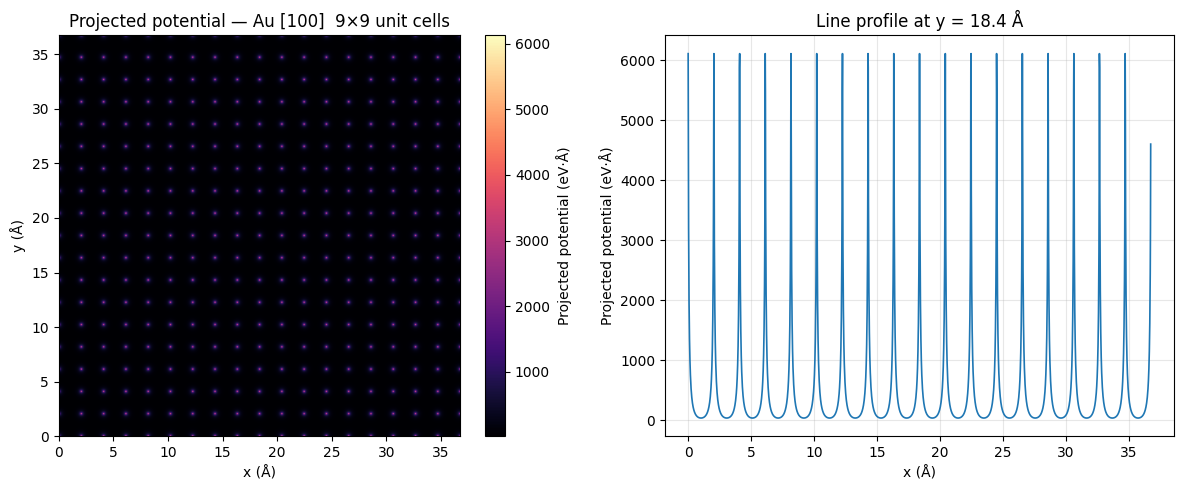

In [4]:
# Project the test potential along z (sum over slices, scaled by dz).
if pot_test_cell is None:
    print("Rebuilding test one-cell potential for projected-potential plot...")
    pot_test_abtem = abtem.Potential(
        unit_supercell, gpts=gpts, slice_thickness=dz_test,
        projection="finite", parametrization="lobato",
    )
    pot_test_cell = jnp.array(cupy.asnumpy(pot_test_abtem.build(lazy=False).array) / dz_test)
    del pot_test_abtem
    cupy.get_default_memory_pool().free_all_blocks()

proj_pot = np.asarray(pot_test_cell).sum(axis=0) * dz_test  # eV·Å  (projected potential)

extent_xy_A = [0, nx_rep * unit_cell.cell.lengths()[0],
               0, ny_rep * unit_cell.cell.lengths()[1]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

im = ax1.imshow(proj_pot, origin="lower", extent=extent_xy_A, cmap="magma")
ax1.set_title(f"Projected potential — Au [100]  {nx_rep}×{ny_rep} unit cells")
ax1.set_xlabel("x (Å)")
ax1.set_ylabel("y (Å)")
plt.colorbar(im, ax=ax1, label="Projected potential (eV·Å)")

# Line profile through the centre along x.
centre_y = proj_pot.shape[0] // 2
x_axis_A = np.linspace(extent_xy_A[0], extent_xy_A[1], proj_pot.shape[1])
ax2.plot(x_axis_A, proj_pot[centre_y, :], linewidth=1.2)
ax2.set_title(f"Line profile at y = {extent_xy_A[3]/2:.1f} Å")
ax2.set_xlabel("x (Å)")
ax2.set_ylabel("Projected potential (eV·Å)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Load or run thickness-resolved CBED series



If a compact results file already exists, the notebook can reconstruct the stored error curves and final CBED patterns without rerunning the expensive propagation. Set `RECOMPUTE_SIMULATION = True` to regenerate the data.

In [5]:
def results_file_path():
    return resolve_repo_root() / "notebooks" / "cbed" / "results" / RESULTS_FILENAME


def reconstruct_results_from_npz(path):
    with np.load(path, allow_pickle=True) as data:
        loaded_methods = [str(name) for name in data["method_names"]]
        loaded_angles = data["probe_angles_mrad"].astype(float)
        loaded_metadata = dict(data["metadata"][0])
        loaded_error_metric = str(loaded_metadata.get("error_metric", "cbed_intensity_rmse"))
        if loaded_error_metric != "cbed_amplitude_rmse":
            raise ValueError(
                "Saved CBED results contain diffraction-intensity RMSE curves. "
                "Set RECOMPUTE_SIMULATION = True and rerun from the potential-building cell "
                "to regenerate amplitude-based curves."
            )
        loaded_results = {
            "metadata": loaded_metadata,
            "thickness_nm": data["thickness_nm"].copy(),
            "angles": {},
        }
        for alpha in loaded_angles:
            angle_key = f"angle_{alpha:.0f}mrad"
            angle_results = {
                "rel_l2": {},
                "runtime_s": {},
                "final_patterns": {},
                "final_exit_waves": {},
            }
            for method in loaded_methods:
                key = method_key(method)
                angle_results["rel_l2"][method] = data[f"{angle_key}_{key}_rel_l2"].copy()
                angle_results["runtime_s"][method] = data[f"{angle_key}_{key}_runtime_s"].copy()
                angle_results["final_patterns"][method] = data[f"{angle_key}_{key}_final_pattern"].copy()
            loaded_results["angles"][float(alpha)] = angle_results
    return loaded_angles, loaded_methods, loaded_results


# Methods compared against WP-MS (the reference).
compare_method_names = ["Fresnel MS", "Angular Spectrum"]
all_method_names = compare_method_names + ["WPM"]

existing_results_path = results_file_path()

if LOAD_EXISTING_RESULTS and existing_results_path.exists() and not RECOMPUTE_SIMULATION:
    PROBE_ANGLES_MRAD, loaded_names, cbed_results = reconstruct_results_from_npz(existing_results_path)
    thickness_nm = cbed_results["thickness_nm"]
    print(f"Loaded saved CBED results -> {existing_results_path}")
    print(f"Loaded {len(PROBE_ANGLES_MRAD)} angles and {len(thickness_nm)} thickness points")
else:
    cbed_results = {
        "metadata": {
            "energy_eV": energy,
            "wavelength_A": wavelength,
            "lattice_constant_A": a_Au,
            "gpts": gpts,
            "sampling_A": sampling,
            "target_thickness_nm": TARGET_THICKNESS_NM,
            "actual_thickness_nm": actual_thickness_nm,
            "n_unit_cells": n_unit_cells,
            "test_slices_per_cell": TEST_SLICES_PER_CELL,
            "wpm_n_bins": WPM_N_BINS,
            "potential_parametrization": "lobato",
            "potential_projection": "finite",
            "index_model": "kg",
            "ms_phase_convention": "paraxial_n2",
            "probe_angles_mrad": PROBE_ANGLES_MRAD.copy(),
            "error_metric": "cbed_amplitude_rmse",
            "reference_method": "WPM",
        },
        "thickness_nm": thickness_nm.copy(),
        "angles": {},
    }

    for alpha in PROBE_ANGLES_MRAD:
        print("=" * 72)
        print(f"Angle {alpha:.0f} mrad: propagating {n_unit_cells} unit cells")
        print("=" * 72)

        probe = make_convergent_probe(alpha, ny_g, nx_g, sampling[0], sampling[1], wavelength)

        waves = {
            "Fresnel MS": probe,
            "Angular Spectrum": probe,
            "WPM": probe,
        }

        angle_results = {
            "rel_l2": {name: np.empty(n_unit_cells, dtype=float) for name in compare_method_names},
            "runtime_s": {name: np.empty(n_unit_cells, dtype=float) for name in all_method_names},
            "final_patterns": {},
            "final_exit_waves": {},
        }

        for cell_index in range(n_unit_cells):
            if cell_index == 0 or (cell_index + 1) % 25 == 0 or (cell_index + 1) == n_unit_cells:
                print(f"  Unit cell {cell_index + 1}/{n_unit_cells} ({thickness_nm[cell_index]:.1f} nm)")

            # WP-MS — reference method.
            t0 = perf_counter()
            waves["WPM"] = simulate_wpm_exit_only(
                pot_test_cell,
                waves["WPM"],
                dz_test,
                energy,
                sampling,
                n_bins=WPM_N_BINS,
                bin_batch_size=4,
            )
            jax.block_until_ready(waves["WPM"])
            angle_results["runtime_s"]["WPM"][cell_index] = perf_counter() - t0
            dp_wpm = diffraction_pattern_numpy(waves["WPM"])
            amp_ref = cbed_amplitude(dp_wpm)

            # Fresnel multislice.
            t0 = perf_counter()
            waves["Fresnel MS"] = simulate_fresnel_as_exit_only(
                pot_test_cell,
                waves["Fresnel MS"],
                fk,
                dz_test,
                energy,
            )
            jax.block_until_ready(waves["Fresnel MS"])
            angle_results["runtime_s"]["Fresnel MS"][cell_index] = perf_counter() - t0
            dp_fresnel = diffraction_pattern_numpy(waves["Fresnel MS"])
            angle_results["rel_l2"]["Fresnel MS"][cell_index] = relative_rmse(cbed_amplitude(dp_fresnel), amp_ref)

            # Angular spectrum.
            t0 = perf_counter()
            waves["Angular Spectrum"] = simulate_fresnel_as_exit_only(
                pot_test_cell,
                waves["Angular Spectrum"],
                ak,
                dz_test,
                energy,
            )
            jax.block_until_ready(waves["Angular Spectrum"])
            angle_results["runtime_s"]["Angular Spectrum"][cell_index] = perf_counter() - t0
            dp_as = diffraction_pattern_numpy(waves["Angular Spectrum"])
            angle_results["rel_l2"]["Angular Spectrum"][cell_index] = relative_rmse(cbed_amplitude(dp_as), amp_ref)

        angle_results["final_patterns"]["WPM"] = dp_wpm
        angle_results["final_patterns"]["Fresnel MS"] = diffraction_pattern_numpy(waves["Fresnel MS"])
        angle_results["final_patterns"]["Angular Spectrum"] = diffraction_pattern_numpy(waves["Angular Spectrum"])

        angle_results["final_exit_waves"] = {name: np.asarray(wave) for name, wave in waves.items()}
        cbed_results["angles"][float(alpha)] = angle_results
        cupy.get_default_memory_pool().free_all_blocks()

    print("Thickness-resolved CBED series complete.")


Angle 5 mrad: propagating 246 unit cells
  Unit cell 1/246 (0.4 nm)
  Unit cell 25/246 (10.2 nm)
  Unit cell 50/246 (20.4 nm)
  Unit cell 75/246 (30.6 nm)
  Unit cell 100/246 (40.8 nm)
  Unit cell 125/246 (51.0 nm)
  Unit cell 150/246 (61.2 nm)
  Unit cell 175/246 (71.4 nm)
  Unit cell 200/246 (81.6 nm)
  Unit cell 225/246 (91.8 nm)
  Unit cell 246/246 (100.4 nm)
Thickness-resolved CBED series complete.


## Save compact results for later plotting



The saved file contains metadata, the thickness axis, per-method error curves, runtime curves, and final CBED patterns. It does not store every full diffraction pattern at every thickness, which would be several gigabytes.

In [6]:
if SAVE_RESULTS_NPZ:
    repo_root = Path.cwd().resolve()
    for base in [repo_root, *repo_root.parents]:
        if (base / "notebooks").exists() and (base / "Paper").exists():
            repo_root = base
            break

    output_dir = repo_root / "notebooks" / "cbed" / "results"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / RESULTS_FILENAME

    arrays_to_save = {
        "thickness_nm": cbed_results["thickness_nm"],
        "probe_angles_mrad": PROBE_ANGLES_MRAD,
        "method_names": np.array(all_method_names, dtype=object),
        "gpts": np.array(gpts),
        "sampling_A": np.array(sampling),
        "metadata": np.array([cbed_results["metadata"]], dtype=object),
        "central_zoom_outer_fraction": np.array(CENTRAL_ZOOM_OUTER_FRACTION),
    }
    for alpha, angle_results in cbed_results["angles"].items():
        angle_key = f"angle_{alpha:.0f}mrad"
        for method in all_method_names:
            method_slug = method_key(method)
            arrays_to_save[f"{angle_key}_{method_slug}_rel_l2"] = angle_results["rel_l2"].get(method, np.array([]))
            arrays_to_save[f"{angle_key}_{method_slug}_runtime_s"] = angle_results["runtime_s"][method]
            arrays_to_save[f"{angle_key}_{method_slug}_final_pattern"] = angle_results["final_patterns"][method]

    np.savez_compressed(output_path, **arrays_to_save)
    print(f"Saved compact results -> {output_path}")


Saved compact results -> /home/dl277493/Documents/Code/WideAnglePropagation-main/notebooks/cbed/results/exploratory_cbed_thickness_series_au100_100nm.npz


## Error versus thickness

Each panel is one probe semi-angle.

Curves show relative RMSE of CBED diffraction-pattern amplitude against the WP-MS reference at the end of every unit cell, not exit-wave amplitude.

Lower values indicate closer agreement. Values above 1 are possible for large deviations.

Saved figure -> /home/dl277493/Documents/Code/WideAnglePropagation-main/Paper/figures/Figure_7.pdf
Saved figure -> /home/dl277493/Documents/Code/WideAnglePropagation-main/Paper/figures/Figure_7.png


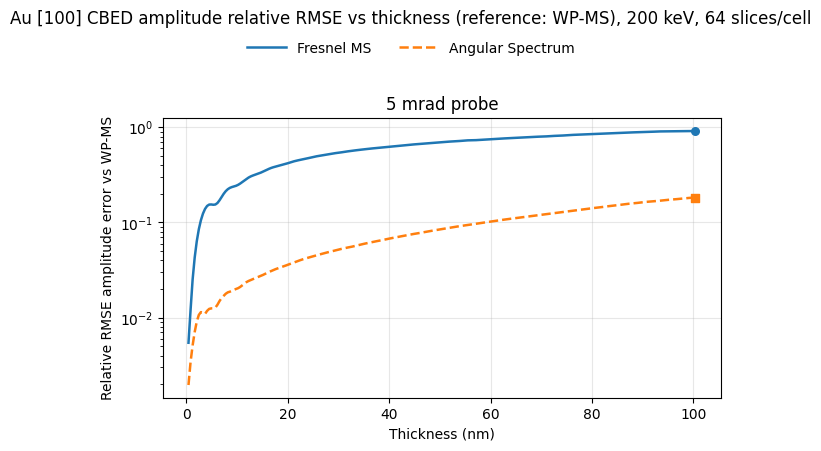

In [7]:
colors = {"Fresnel MS": "C0", "Angular Spectrum": "C1"}
line_styles = {"Fresnel MS": "-", "Angular Spectrum": "--"}
end_markers = {"Fresnel MS": "o", "Angular Spectrum": "s"}

SAVE_ERROR_THICKNESS_FIGURE = True
ERROR_THICKNESS_FIGURE_BASENAME = "Figure_7"

_has_error_data = any(
    np.any(np.isfinite(cbed_results["angles"][float(a)]["rel_l2"][m]))
    for a in PROBE_ANGLES_MRAD for m in compare_method_names
)
if not _has_error_data:
    print("WARNING: No finite rel_l2 error data — skipping error-vs-thickness plot.")

if _has_error_data:
    n_angles = len(PROBE_ANGLES_MRAD)
    ncols = min(2, n_angles)
    nrows = int(np.ceil(n_angles / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.8 * nrows), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(-1)

    legend_handles = {}
    for panel_index, (ax, alpha) in enumerate(zip(axes, PROBE_ANGLES_MRAD)):
        angle_results = cbed_results["angles"][float(alpha)]
        x = cbed_results["thickness_nm"]
        for method in compare_method_names:
            y = angle_results["rel_l2"][method]
            line, = ax.semilogy(x, y, color=colors[method], linestyle=line_styles[method], linewidth=1.8, label=method)
            ax.scatter(x[-1], y[-1], color=colors[method], marker=end_markers[method], s=30, zorder=4)
            if method not in legend_handles:
                legend_handles[method] = line
        ax.set_title(f"{alpha:.0f} mrad probe")
        if n_angles > 1:
            ax.set_title(f"({chr(ord('a') + panel_index)})", loc="left", fontsize=11, fontweight="bold", pad=4)
        ax.set_xlabel("Thickness (nm)")
        ax.set_ylabel("Relative RMSE amplitude error vs WP-MS")
        ax.grid(True, alpha=0.3)

    for ax in axes[n_angles:]:
        ax.axis("off")

    fig.suptitle(f"Au [100] CBED amplitude relative RMSE vs thickness (reference: WP-MS), {energy/1e3:.0f} keV, {TEST_SLICES_PER_CELL} slices/cell", fontsize=12, y=0.98)

    ordered_handles = [legend_handles[m] for m in compare_method_names if m in legend_handles]
    ordered_labels = [m for m in compare_method_names if m in legend_handles]
    fig.legend(ordered_handles, ordered_labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncol=max(1, len(ordered_labels)), frameon=False, fontsize=10, handlelength=2.8)

    plt.tight_layout(rect=[0.0, 0.05, 1.0, 0.90])

    error_thickness_fig_dir = REPO_ROOT / "Paper" / "figures"
    error_thickness_fig_dir.mkdir(parents=True, exist_ok=True)
    error_thickness_pdf_path = error_thickness_fig_dir / f"{ERROR_THICKNESS_FIGURE_BASENAME}.pdf"
    error_thickness_png_path = error_thickness_fig_dir / f"{ERROR_THICKNESS_FIGURE_BASENAME}.png"
    fig.savefig(error_thickness_pdf_path, format="pdf", bbox_inches="tight", dpi=600)
    fig.savefig(error_thickness_png_path, format="png", bbox_inches="tight", dpi=600)
    print(f"Saved figure -> {error_thickness_pdf_path}")
    print(f"Saved figure -> {error_thickness_png_path}")

    plt.show()


## Paper-ready combined CBED figure

Per probe angle, shows the WP-MS CBED amplitude alongside each test method's amplitude and its pixel-wise percent amplitude error on a shared log color scale. Exports the paper artwork as `Paper/figures/Figure_6.pdf`.

Saved -> /home/dl277493/Documents/Code/WideAnglePropagation-main/Paper/figures/Figure_6.pdf


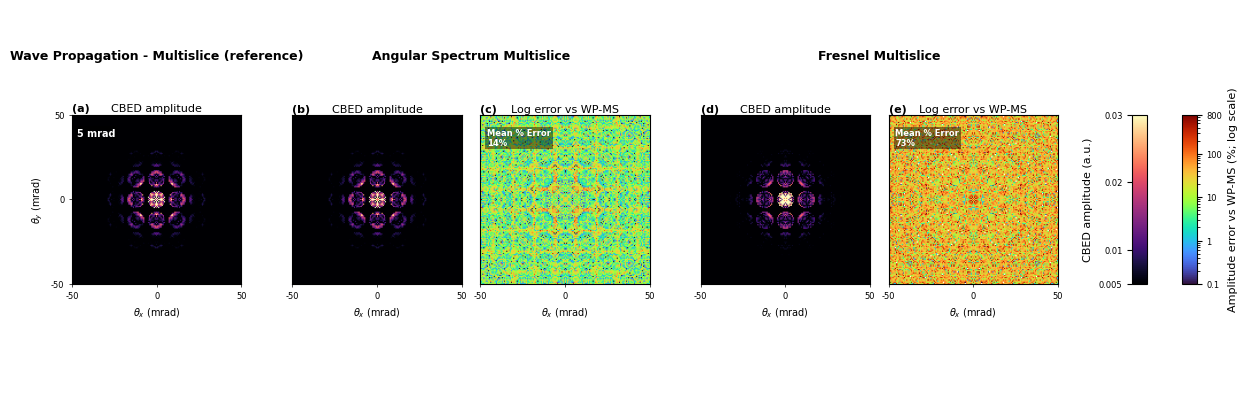

In [8]:
# Paper-ready combined CBED amplitude + log percent-error figure (WP-MS reference).
from matplotlib.colors import Normalize

# --- Tunable controls -------------------------------------------------
RESULTS_FILENAME = globals().get("RESULTS_FILENAME", "exploratory_cbed_thickness_series_au100_100nm.npz")
COMBINED_OUTPUT_FILENAME = "Figure_6.pdf"
CENTRAL_VIEW_CUTOFF_MRAD = globals().get("CENTRAL_VIEW_CUTOFF_MRAD", 100.0)
EXCLUDED_PROBE_ANGLES_MRAD = [200.0]

METHOD_PLOT_ORDER = ["Angular Spectrum", "Fresnel MS"]
METHOD_DISPLAY_LABELS = {
    "WPM": "Wave Propagation Multislice (reference)",
    "Angular Spectrum": "Angular Spectrum Multislice",
    "Fresnel MS": "Fresnel Multislice",
}

AMPLITUDE_CMAP = "magma"
ERROR_CMAP = "turbo"
AMPLITUDE_VMIN, AMPLITUDE_VMAX = 0.005, 0.03
AMPLITUDE_TICKS = [0.005, 0.01, 0.02, 0.03]
ERROR_FLOOR_PCT = 0.1
ERROR_VMIN, ERROR_VMAX = ERROR_FLOOR_PCT, 800.0
ERROR_TICKS = [ERROR_VMIN, 1.0, 10.0, 100.0, ERROR_VMAX]
ERROR_TICK_LABELS = ["0.1", "1", "10", "100", f"{ERROR_VMAX:.0f}"]

THETA_TICKS = [-50.0, 0.0, 50.0]
THETA_TICK_LABELS = ["-50", "0", "50"]

FIGSIZE = (12.4, 5.5)
GRID_PANEL_WIDTH = 1.0
GROUP_SPACER_WIDTH = 0.08
SUBPLOT_KW = dict(left=0.055, right=0.85, bottom=0.10, top=0.79, wspace=0.15, hspace=0.08)
COLORBAR_WIDTH = 0.012
AMPLITUDE_COLORBAR_X = 0.910
ERROR_COLORBAR_X = 0.950

# Standalone fallback: load results from the saved NPZ if the notebook state is empty.
_required = (
    "compare_method_names", "all_method_names", "PROBE_ANGLES_MRAD", "cbed_results",
    "gpts", "sampling", "ny_g", "nx_g", "wavelength", "actual_thickness_nm",
)
if any(name not in globals() for name in _required):
    results_path = resolve_repo_root() / "notebooks" / "cbed" / "results" / RESULTS_FILENAME
    with np.load(results_path, allow_pickle=True) as data:
        all_method_names = [str(name) for name in data["method_names"]]
        compare_method_names = [m for m in all_method_names if m != "WPM"]
        PROBE_ANGLES_MRAD = data["probe_angles_mrad"].astype(float)
        gpts = tuple(int(v) for v in data["gpts"])
        sampling = tuple(float(v) for v in data["sampling_A"])
        ny_g, nx_g = gpts
        metadata = dict(data["metadata"][0])
        wavelength = float(metadata["wavelength_A"])
        actual_thickness_nm = float(metadata["actual_thickness_nm"])
        cbed_results = {"angles": {}}
        for alpha in PROBE_ANGLES_MRAD:
            angle_key = f"angle_{alpha:.0f}mrad"
            patterns = {}
            for method in all_method_names:
                patterns[method] = data[f"{angle_key}_{method_key(method)}_final_pattern"].copy()
            cbed_results["angles"][float(alpha)] = {"final_patterns": patterns}

# WP-MS is always the reference.
compare_methods = (
    [m for m in METHOD_PLOT_ORDER if m in compare_method_names]
    + [m for m in compare_method_names if m not in METHOD_PLOT_ORDER]
)
excluded = np.array(EXCLUDED_PROBE_ANGLES_MRAD, dtype=float)
figure_probe_angles_mrad = np.array(
    [float(a) for a in PROBE_ANGLES_MRAD
     if excluded.size == 0 or not np.any(np.isclose(float(a), excluded))],
    dtype=float,
)

panel_cache = {}
for alpha in figure_probe_angles_mrad:
    angle_data = cbed_results["angles"][float(alpha)]
    y_slice, x_slice, theta_y, theta_x = central_crop_slices_by_cutoff(
        CENTRAL_VIEW_CUTOFF_MRAD, ny_g, nx_g, sampling[0], sampling[1], wavelength,
    )
    extent = [theta_x[x_slice.start], theta_x[x_slice.stop - 1],
              theta_y[y_slice.start], theta_y[y_slice.stop - 1]]
    amp_ref = cbed_amplitude(angle_data["final_patterns"]["WPM"][y_slice, x_slice])
    cache = {"extent": extent, "amplitude": {"WPM": amp_ref}, "error_pct": {}}
    for method in compare_methods:
        amp_method = cbed_amplitude(angle_data["final_patterns"][method][y_slice, x_slice])
        cache["amplitude"][method] = amp_method
        cache["error_pct"][method] = 100.0 * np.abs(amp_method - amp_ref) / np.maximum(amp_ref, 1e-12)
    panel_cache[float(alpha)] = cache

amplitude_norm = Normalize(vmin=AMPLITUDE_VMIN, vmax=AMPLITUDE_VMAX, clip=True)
error_norm = LogNorm(vmin=ERROR_VMIN, vmax=ERROR_VMAX)
error_cmap = plt.get_cmap(ERROR_CMAP).copy()
error_cmap.set_under("white")
error_cmap.set_over("white")

def _error_label(error_pct):
    values = np.asarray(error_pct)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return "Mean % Error\nn/a"
    mean = float(np.mean(values))
    if mean < 0.01:     text = f"{mean:.1e}%"
    elif mean < 1.0:    text = f"{mean:.2f}%"
    elif mean < 10.0:   text = f"{mean:.2g}%"
    elif mean < 1000.0: text = f"{mean:.0f}%"
    else:               text = f"{mean:.1e}%"
    return f"Mean % Error\n{text}"

# Build groups: WP-MS reference column, then each compare method with amplitude + error.
groups = [("Wave Propagation - Multislice (reference)", ["WPM"])]
for m in compare_methods:
    groups.append((METHOD_DISPLAY_LABELS.get(m, m), [f"{m} amplitude", f"{m} error"]))

grid_columns = []
width_ratios = []
for i, (_, cols) in enumerate(groups):
    if i > 0:
        grid_columns.append(("spacer", None))
        width_ratios.append(GROUP_SPACER_WIDTH)
    for col in cols:
        grid_columns.append(("panel", col))
        width_ratios.append(GRID_PANEL_WIDTH)

nrows = len(figure_probe_angles_mrad)
fig, grid_axes = plt.subplots(nrows, len(grid_columns), figsize=FIGSIZE,
                              gridspec_kw={"width_ratios": width_ratios})
grid_axes = np.asarray(grid_axes).reshape(nrows, len(grid_columns))
panel_axes = {col: grid_axes[:, idx] for idx, (kind, col) in enumerate(grid_columns) if kind == "panel"}
for idx, (kind, _) in enumerate(grid_columns):
    if kind == "spacer":
        for ax in grid_axes[:, idx]:
            ax.axis("off")

amplitude_im = error_im = None
for row, alpha in enumerate(figure_probe_angles_mrad):
    key = float(alpha)
    extent = panel_cache[key]["extent"]
    # WP-MS reference column.
    amplitude_im = panel_axes["WPM"][row].imshow(
        panel_cache[key]["amplitude"]["WPM"],
        norm=amplitude_norm, cmap=AMPLITUDE_CMAP, origin="lower", extent=extent,
    )
    panel_axes["WPM"][row].text(
        0.03, 0.92, f"{alpha:.0f} mrad",
        transform=panel_axes["WPM"][row].transAxes, ha="left", va="top",
        color="white", fontsize=7, fontweight="bold",
        bbox={"facecolor": "black", "alpha": 0.45, "edgecolor": "none", "pad": 1.5},
    )
    for method in compare_methods:
        amplitude_im = panel_axes[f"{method} amplitude"][row].imshow(
            panel_cache[key]["amplitude"][method],
            norm=amplitude_norm, cmap=AMPLITUDE_CMAP, origin="lower", extent=extent,
        )
        error_data = panel_cache[key]["error_pct"][method]
        error_im = panel_axes[f"{method} error"][row].imshow(
            np.maximum(error_data, ERROR_FLOOR_PCT),
            norm=error_norm, cmap=error_cmap, origin="lower", extent=extent,
        )
        panel_axes[f"{method} error"][row].text(
            0.04, 0.92, _error_label(panel_cache[key]["error_pct"][method]),
            transform=panel_axes[f"{method} error"][row].transAxes, ha="left", va="top",
            color="white", fontsize=6, fontweight="bold",
            bbox={"facecolor": "black", "alpha": 0.45, "edgecolor": "none", "pad": 1.2},
        )

for row in range(nrows):
    for col_idx, (kind, column) in enumerate(grid_columns):
        if kind != "panel":
            continue
        ax = grid_axes[row, col_idx]
        ax.tick_params(labelsize=6, length=2, width=0.5)
        if row == nrows - 1:
            ax.set_xticks(THETA_TICKS, THETA_TICK_LABELS)
            ax.set_xlabel(r"$\theta_x$ (mrad)", fontsize=7)
        else:
            ax.set_xticks([])
        if column == "WPM":
            ax.set_yticks(THETA_TICKS, THETA_TICK_LABELS)
            ax.set_ylabel(r"$\theta_y$ (mrad)", fontsize=7)
        else:
            ax.set_yticks([])

panel_axes["WPM"][0].set_title("CBED amplitude", fontsize=8)
for method in compare_methods:
    panel_axes[f"{method} amplitude"][0].set_title("CBED amplitude", fontsize=8)
    panel_axes[f"{method} error"][0].set_title("Log error vs WP-MS", fontsize=8)

panel_columns = [column for kind, column in grid_columns if kind == "panel"]
for panel_index, column in enumerate(panel_columns):
    panel_axes[column][0].set_title(
        f"({chr(ord('a') + panel_index)})",
        loc="left",
        fontsize=8,
        fontweight="bold",
        pad=2,
    )

fig.subplots_adjust(**SUBPLOT_KW)
for group_label, cols in groups:
    positions = [panel_axes[c][0].get_position() for c in cols]
    left = min(p.x0 for p in positions)
    right = max(p.x1 for p in positions)
    fig.text((left + right) / 2.0, 0.705, group_label,
             ha="center", va="center", fontsize=9, fontweight="bold")

top_positions = [panel_axes["WPM"][r].get_position() for r in range(nrows)]
cbar_bottom = min(p.y0 for p in top_positions)
cbar_height = max(p.y1 for p in top_positions) - cbar_bottom

amp_cax = fig.add_axes([AMPLITUDE_COLORBAR_X, cbar_bottom, COLORBAR_WIDTH, cbar_height])
amp_cbar = fig.colorbar(amplitude_im, cax=amp_cax)
amp_cbar.set_label("CBED amplitude (a.u.)", fontsize=8)
amp_cbar.set_ticks(AMPLITUDE_TICKS)
amp_cbar.ax.set_yticklabels([f"{t:g}" for t in AMPLITUDE_TICKS])
amp_cbar.ax.yaxis.set_ticks_position("left")
amp_cbar.ax.yaxis.set_label_position("left")
amp_cbar.ax.tick_params(labelsize=6)

err_cax = fig.add_axes([ERROR_COLORBAR_X, cbar_bottom, COLORBAR_WIDTH, cbar_height])
err_cbar = fig.colorbar(error_im, cax=err_cax)
err_cbar.set_label("Amplitude error vs WP-MS (%; log scale)", fontsize=8)
err_cbar.set_ticks(ERROR_TICKS)
err_cbar.ax.set_yticklabels(ERROR_TICK_LABELS)
err_cbar.ax.tick_params(labelsize=6)

combined_fig_dir = resolve_repo_root() / "Paper" / "figures"
combined_fig_dir.mkdir(parents=True, exist_ok=True)
combined_path = combined_fig_dir / COMBINED_OUTPUT_FILENAME
fig.savefig(combined_path, format="pdf", bbox_inches="tight", dpi=600)
print(f"Saved -> {combined_path}")
plt.show()


## Central-axis beam cross-section

Propagate the probe through the crystal for one chosen probe angle and store the
central row of the wavefunction amplitude at every slice for each method
(WP-MS, Fresnel MS, Angular Spectrum). The result is a 2D image
(x vs z) per method, plotted as upright panels with the beam entering at
the top. A configurable inset highlights the differences between methods at
a chosen depth. This optional diagnostic is tagged `skip-execution` because it is not used in the paper and would repeat the full propagation.

In [9]:
# --- Cross-section controls -------------------------------------------------
CROSS_SECTION_PROBE_ANGLE_MRAD = 5.0          # which probe angle to slice
CROSS_SECTION_N_CELLS = n_unit_cells            # number of unit cells to propagate
CROSS_SECTION_SAVE_EVERY = 1                    # store amplitude every N slices (1 = every slice)
CROSS_SECTION_RESULTS_FILENAME = (
    f"cbed_cross_section_au100_{int(CROSS_SECTION_PROBE_ANGLE_MRAD):d}mrad.npz"
)
LOAD_EXISTING_CROSS_SECTION = True
RECOMPUTE_CROSS_SECTION = False

# Two inset zoom windows (nm depth, Å transverse)
# Zoom 1 is shown in the first zoom row; zoom 2 in the second.
INSET1_Z_RANGE_NM = (10.0, 25.0)
INSET1_X_RANGE_A = (-3.0, 3.0)
INSET2_Z_RANGE_NM = (60.0, 80.0)
INSET2_X_RANGE_A = (-3.0, 3.0)
INSET_ROW_HEIGHT_RATIO = 1.15                   # each zoom-row height relative to the main row

# Color normalization for plotting (shared across all methods/panels)
NORMALIZE_COLORBAR = True
COLORBAR_PERCENTILE = 99.5

# Figure export
SAVE_CROSS_SECTION_FIGURE = True
CROSS_SECTION_FIGURE_BASENAME = f"cbed_cross_section_au100_{int(CROSS_SECTION_PROBE_ANGLE_MRAD):d}mrad"

# --- Storage paths ---------------------------------------------------------
cross_section_path = resolve_repo_root() / "notebooks" / "cbed" / "results" / CROSS_SECTION_RESULTS_FILENAME
cross_section_fig_dir = resolve_repo_root() / "notebooks" / "cbed" / "results"

preferred_cross_section_order = ["WPM", "Angular Spectrum", "Fresnel MS"]


def _ordered_cross_section_methods(available_methods):
    available = list(available_methods)
    return [m for m in preferred_cross_section_order if m in available]


_cs_base_methods = ["WPM", "Angular Spectrum", "Fresnel MS"]
cross_section_methods = _ordered_cross_section_methods(_cs_base_methods)


def _central_row_amplitude(wavefronts_jax):
    """Take central row amplitude from a stack of complex wavefronts of shape (N, ny, nx)."""
    arr = np.asarray(wavefronts_jax)
    return np.abs(arr[:, arr.shape[1] // 2, :]).astype(np.float32)


def _ensure_potentials_for_cross_section():
    """Rebuild one-cell test potential and Fresnel/AS kernels if they were skipped at load time."""
    global pot_test_cell, fk, ak
    if pot_test_cell is None:
        print("Building test one-cell potential for cross-section...")
        pot_test_abtem = abtem.Potential(
            unit_supercell, gpts=gpts, slice_thickness=dz_test,
            projection="finite", parametrization="lobato",
        )
        pot_test_cell = jnp.array(cupy.asnumpy(pot_test_abtem.build(lazy=False).array) / dz_test)
        del pot_test_abtem
        cupy.get_default_memory_pool().free_all_blocks()
        fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=dz_test, energy=energy))
        ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=dz_test, energy=energy))


def _run_cross_section_simulation(n_cells, save_every):
    """Propagate one probe and return {method: (n_z, nx) amplitude}, z_axis_A, x_axis_A."""
    _ensure_potentials_for_cross_section()
    probe = make_convergent_probe(
        CROSS_SECTION_PROBE_ANGLE_MRAD, ny_g, nx_g, sampling[0], sampling[1], wavelength,
    )

    def _stride(stack):
        """Subsample along the slice axis."""
        return stack[::save_every]

    method_rows = {name: [] for name in cross_section_methods}
    # Initial (z = 0) row, identical for all methods
    initial_row = np.abs(np.asarray(probe)[ny_g // 2, :]).astype(np.float32)
    for name in cross_section_methods:
        method_rows[name].append(initial_row[None, :])

    # WP-MS (reference) + Angular Spectrum + Fresnel
    for method_name, runner in [
        ("WPM", lambda w: simulate_wpm(pot_test_cell, w, dz_test, energy, sampling, n_bins=WPM_N_BINS)),
        ("Angular Spectrum", lambda w: simulate_fresnel_as(pot_test_cell, w, ak, dz_test, energy)),
        ("Fresnel MS", lambda w: simulate_fresnel_as(pot_test_cell, w, fk, dz_test, energy)),
    ]:
        print(f"Cross-section: {method_name} over {n_cells} unit cells...")
        wave = probe
        for ci in range(n_cells):
            wave, _, wavefronts = runner(wave)
            method_rows[method_name].append(_stride(_central_row_amplitude(wavefronts)))
            if (ci + 1) % 25 == 0 or (ci + 1) == n_cells:
                print(f"  {method_name} cell {ci + 1}/{n_cells}")
        cupy.get_default_memory_pool().free_all_blocks()

    method_amplitudes = {name: np.concatenate(parts, axis=0) for name, parts in method_rows.items()}

    # z axis (Å).
    n_test_rows = method_amplitudes["Fresnel MS"].shape[0]
    z_axis_test_A = np.concatenate([[0.0], dz_test * (np.arange(1, n_cells * TEST_SLICES_PER_CELL + 1)[(save_every - 1)::save_every])])
    z_axis_test_A = z_axis_test_A[:n_test_rows]

    x_axis_A = (np.arange(nx_g) - nx_g // 2) * sampling[1]
    return method_amplitudes, z_axis_test_A, x_axis_A


# --- Load or compute ------------------------------------------------------
if (
    LOAD_EXISTING_CROSS_SECTION
    and cross_section_path.exists()
    and not RECOMPUTE_CROSS_SECTION
):
    with np.load(cross_section_path, allow_pickle=True) as cs_data:
        loaded_cs_methods = [str(name) for name in cs_data["method_names"]]
        cross_section_amplitude = {}
        for name in loaded_cs_methods:
            key = f"amplitude_{str(name).lower().replace(' ', '_')}"
            if key in cs_data:
                cross_section_amplitude[str(name)] = cs_data[key].copy()
        cross_section_methods = _ordered_cross_section_methods(cross_section_amplitude.keys())
        cross_section_z_test_A = cs_data["z_axis_test_A"].copy()
        cross_section_x_A = cs_data["x_axis_A"].copy()
        cross_section_meta = dict(cs_data["metadata"][0])
    print(f"Loaded cross-section -> {cross_section_path}")
else:
    cross_section_amplitude, cross_section_z_test_A, cross_section_x_A = (
        _run_cross_section_simulation(CROSS_SECTION_N_CELLS, CROSS_SECTION_SAVE_EVERY)
    )
    cross_section_methods = _ordered_cross_section_methods(cross_section_amplitude.keys())
    cross_section_meta = {
        "probe_angle_mrad": float(CROSS_SECTION_PROBE_ANGLE_MRAD),
        "n_unit_cells": int(CROSS_SECTION_N_CELLS),
        "save_every": int(CROSS_SECTION_SAVE_EVERY),
        "energy_eV": float(energy),
        "wavelength_A": float(wavelength),
        "sampling_A": tuple(float(v) for v in sampling),
        "gpts": tuple(int(v) for v in gpts),
        "test_slices_per_cell": int(TEST_SLICES_PER_CELL),
    }
    cross_section_path.parent.mkdir(parents=True, exist_ok=True)
    save_arrays = {
        "method_names": np.array(cross_section_methods, dtype=object),
        "z_axis_test_A": cross_section_z_test_A,
        "x_axis_A": cross_section_x_A,
        "metadata": np.array([cross_section_meta], dtype=object),
    }
    for name, arr in cross_section_amplitude.items():
        save_arrays[f"amplitude_{name.lower().replace(' ', '_')}"] = arr
    np.savez_compressed(cross_section_path, **save_arrays)
    print(f"Saved cross-section -> {cross_section_path}")


# --- Plot ----------------------------------------------------------------
from matplotlib.patches import Rectangle

# Shared plotting scale across all methods/panels
all_vals = np.concatenate([a.ravel() for a in cross_section_amplitude.values()])
if NORMALIZE_COLORBAR:
    amp_scale = float(np.percentile(all_vals, COLORBAR_PERCENTILE))
    amp_scale = amp_scale if amp_scale > 0.0 else 1.0
    cross_section_amplitude_plot = {
        name: (arr / amp_scale).astype(np.float32)
        for name, arr in cross_section_amplitude.items()
    }
    amp_vmin = 0.0
    amp_vmax = 1.0
    cbar_label = f"Normalized |ψ| (÷ P{COLORBAR_PERCENTILE:.1f})"
else:
    cross_section_amplitude_plot = cross_section_amplitude
    amp_vmin = 0.0
    amp_vmax = float(np.percentile(all_vals, COLORBAR_PERCENTILE))
    cbar_label = "|ψ|"

z_ranges_A = {name: cross_section_z_test_A for name in cross_section_methods}

# Inset bounds
z1_inset_A = (10.0 * INSET1_Z_RANGE_NM[0], 10.0 * INSET1_Z_RANGE_NM[1])
z2_inset_A = (10.0 * INSET2_Z_RANGE_NM[0], 10.0 * INSET2_Z_RANGE_NM[1])

n_panels = len(cross_section_methods)
fig, axes = plt.subplots(
    3,
    n_panels,
    figsize=(3.2 * n_panels + 1.0, 11.8),
    sharey=False,
    squeeze=False,
    gridspec_kw={"height_ratios": [3.0, INSET_ROW_HEIGHT_RATIO, INSET_ROW_HEIGHT_RATIO], "hspace": 0.30},
)
main_axes = axes[0]
zoom1_axes = axes[1]
zoom2_axes = axes[2]

x_min, x_max = cross_section_x_A[0], cross_section_x_A[-1]
last_im = None
for col, method in enumerate(cross_section_methods):
    main_ax = main_axes[col]
    zoom1_ax = zoom1_axes[col]
    zoom2_ax = zoom2_axes[col]
    z_A = z_ranges_A[method]
    amp = cross_section_amplitude_plot[method]
    extent = [x_min, x_max, z_A[-1] / 10.0, z_A[0] / 10.0]  # nm; flipped so top = entry
    im = main_ax.imshow(
        amp, extent=extent, origin="upper", aspect="auto",
        cmap="inferno", vmin=amp_vmin, vmax=amp_vmax, interpolation="nearest",
    )
    last_im = im
    main_ax.set_title(method, fontsize=10)
    if col == 0:
        main_ax.set_ylabel("z (nm), beam direction ↓")
    main_ax.add_patch(
        Rectangle(
            (INSET1_X_RANGE_A[0], INSET1_Z_RANGE_NM[0]),
            INSET1_X_RANGE_A[1] - INSET1_X_RANGE_A[0],
            INSET1_Z_RANGE_NM[1] - INSET1_Z_RANGE_NM[0],
            fill=False,
            edgecolor="cyan",
            linewidth=1.0,
        )
    )
    main_ax.add_patch(
        Rectangle(
            (INSET2_X_RANGE_A[0], INSET2_Z_RANGE_NM[0]),
            INSET2_X_RANGE_A[1] - INSET2_X_RANGE_A[0],
            INSET2_Z_RANGE_NM[1] - INSET2_Z_RANGE_NM[0],
            fill=False,
            edgecolor="lime",
            linewidth=1.0,
        )
    )

    zoom1_ax.imshow(
        amp, extent=extent, origin="upper", aspect="auto",
        cmap="inferno", vmin=amp_vmin, vmax=amp_vmax, interpolation="nearest",
    )
    zoom1_ax.set_xlim(INSET1_X_RANGE_A)
    zoom1_ax.set_ylim(z1_inset_A[1] / 10.0, z1_inset_A[0] / 10.0)  # flipped
    zoom1_ax.set_title(f"{method} zoom 1", fontsize=9, pad=8)
    zoom1_ax.set_xlabel("")
    zoom1_ax.tick_params(labelbottom=False)
    if col == 0:
        zoom1_ax.set_ylabel("zoom 1 z (nm)")
    else:
        zoom1_ax.set_yticklabels([])

    zoom2_ax.imshow(
        amp, extent=extent, origin="upper", aspect="auto",
        cmap="inferno", vmin=amp_vmin, vmax=amp_vmax, interpolation="nearest",
    )
    zoom2_ax.set_xlim(INSET2_X_RANGE_A)
    zoom2_ax.set_ylim(z2_inset_A[1] / 10.0, z2_inset_A[0] / 10.0)  # flipped
    zoom2_ax.set_title(f"{method} zoom 2", fontsize=9, pad=8)
    zoom2_ax.set_xlabel("x (Å)")
    if col == 0:
        zoom2_ax.set_ylabel("zoom 2 z (nm)")
    else:
        zoom2_ax.set_yticklabels([])

for ax in main_axes:
    ax.set_xlabel("")
    ax.tick_params(labelbottom=False)

for ax in zoom1_axes:
    for spine in ax.spines.values():
        spine.set_edgecolor("cyan")
        spine.set_linewidth(1.0)

for ax in zoom2_axes:
    for spine in ax.spines.values():
        spine.set_edgecolor("lime")
        spine.set_linewidth(1.0)

fig.suptitle(
    f"Central-axis beam amplitude, Au [100], probe = {CROSS_SECTION_PROBE_ANGLE_MRAD:.0f} mrad",
    fontsize=12, y=0.995,
)
cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.9, pad=0.02)
cbar.set_label(cbar_label)

cross_section_fig_dir.mkdir(parents=True, exist_ok=True)
cross_section_pdf_path = cross_section_fig_dir / f"{CROSS_SECTION_FIGURE_BASENAME}.pdf"
cross_section_png_path = cross_section_fig_dir / f"{CROSS_SECTION_FIGURE_BASENAME}.png"
fig.savefig(cross_section_pdf_path, format="pdf", bbox_inches="tight", dpi=600)
fig.savefig(cross_section_png_path, format="png", bbox_inches="tight", dpi=600)
print(f"Saved figure -> {cross_section_pdf_path}")
print(f"Saved figure -> {cross_section_png_path}")

plt.show()

Cross-section: WPM over 246 unit cells...


2026-07-16 17:46:32.914438: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.00GiB (rounded to 4294967296)requested by op 
2026-07-16 17:46:32.914602: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] ********************____________***************************************************************____*
E0716 17:46:32.914631 1352204 pjrt_stream_executor_client.cc:3026] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 4294967296 bytes. [tf-allocator-allocation-error='']


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 4294967296 bytes.

## Summary table

In [ ]:
print(f"Au [100], {energy/1e3:.0f} keV, final thickness = {actual_thickness_nm:.1f} nm")
print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
print(f"Z-sampling: {TEST_SLICES_PER_CELL} slices/cell")
print(f"Reference method: WP-MS (n_bins={WPM_N_BINS})")

header = f"{'Angle (mrad)':>12s} {'Method':>18s} {'Final Rel RMSE vs WP-MS':>22s} {'Mean runtime/cell (s)':>22s}"
print(header)
print("-" * len(header))

for alpha in PROBE_ANGLES_MRAD:
    angle_results = cbed_results["angles"][float(alpha)]
    # WP-MS (reference).
    mean_time_wpm = float(np.mean(angle_results["runtime_s"]["WPM"]))
    print(f"{alpha:>12.0f} {'WP-MS (reference)':>18s} {'—':>22s} {mean_time_wpm:>22.3f}")
    for method in compare_method_names:
        final_error = angle_results["rel_l2"][method][-1]
        mean_time = float(np.mean(angle_results["runtime_s"][method]))
        print(f"{alpha:>12.0f} {method:>18s} {final_error:>22.4e} {mean_time:>22.3f}")

## WPM n_bins convergence check

Compare 32- and 64-bin WP-MS over the complete 100.368 nm specimen. This is
the field-convergence check for the 64-bin reference used in Figures 6 and 7.
It is disabled by default because the full 2048 x 2048 calculation is expensive.


In [ ]:
RUN_FULL_THICKNESS_BIN_CONVERGENCE = False
CONVERGENCE_BIN_COUNTS = (32, 64)
CONVERGENCE_CUTOFF_MRAD = 300.0

if RUN_FULL_THICKNESS_BIN_CONVERGENCE:
    import json

    _ensure_potentials_for_cross_section()
    convergence_probe = make_convergent_probe(
        float(PROBE_ANGLES_MRAD[0]), ny_g, nx_g, sampling[0], sampling[1], wavelength
    )
    convergence_runners = {
        bins: jax.jit(
            lambda pot, wave, bins=bins: simulate_wpm_exit_only(
                pot, wave, dz_test, energy, sampling, n_bins=bins,
                power_spacing=2.0, bin_batch_size=4,
            )
        )
        for bins in CONVERGENCE_BIN_COUNTS
    }
    convergence_waves = {bins: convergence_probe for bins in CONVERGENCE_BIN_COUNTS}
    convergence_error = np.empty(n_unit_cells, dtype=float)
    convergence_complex_error = np.empty(n_unit_cells, dtype=float)
    convergence_norm = {bins: np.empty(n_unit_cells, dtype=float) for bins in CONVERGENCE_BIN_COUNTS}
    entrance_norm = float(jnp.sum(jnp.abs(convergence_probe) ** 2))

    fy = np.fft.fftfreq(ny_g, d=sampling[0])
    fx = np.fft.fftfreq(nx_g, d=sampling[1])
    fx_grid, fy_grid = np.meshgrid(fx, fy)
    theta_mrad = 1e3 * np.arcsin(np.clip(wavelength * np.sqrt(fx_grid**2 + fy_grid**2), 0.0, 1.0))
    angular_mask = theta_mrad <= CONVERGENCE_CUTOFF_MRAD

    for cell_index in range(n_unit_cells):
        for bins in CONVERGENCE_BIN_COUNTS:
            convergence_waves[bins] = convergence_runners[bins](
                pot_test_cell, convergence_waves[bins]
            )
            jax.block_until_ready(convergence_waves[bins])
            convergence_norm[bins][cell_index] = float(
                jnp.sum(jnp.abs(convergence_waves[bins]) ** 2) / entrance_norm
            )

        candidate = np.asarray(convergence_waves[CONVERGENCE_BIN_COUNTS[0]])
        reference = np.asarray(convergence_waves[CONVERGENCE_BIN_COUNTS[-1]])
        candidate_amplitude = np.abs(np.fft.fft2(candidate))
        reference_amplitude = np.abs(np.fft.fft2(reference))
        convergence_error[cell_index] = np.linalg.norm(
            (candidate_amplitude - reference_amplitude)[angular_mask]
        ) / max(np.linalg.norm(reference_amplitude[angular_mask]), 1e-30)
        phase = np.angle(np.vdot(reference, candidate))
        convergence_complex_error[cell_index] = np.linalg.norm(
            candidate * np.exp(-1j * phase) - reference
        ) / max(np.linalg.norm(reference), 1e-30)

        if cell_index == 0 or (cell_index + 1) % 10 == 0 or cell_index + 1 == n_unit_cells:
            print(
                f"cell {cell_index + 1:3d}/{n_unit_cells}: "
                f"32/64-bin CBED-amplitude rRMSE = {convergence_error[cell_index]:.6e}"
            )

    convergence_output = REPO_ROOT / "notebooks" / "cbed" / "results" / "au100_wpm_full_thickness_convergence.npz"
    convergence_output.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        convergence_output,
        metadata_json=np.asarray(json.dumps({
            "description": "Au [100] full-thickness WP-MS bin convergence",
            "energy_eV": float(energy),
            "lattice_constant_A": float(a_Au),
            "actual_thickness_nm": float(actual_thickness_nm),
            "n_unit_cells": int(n_unit_cells),
            "lateral_repeats": [int(nx_rep), int(ny_rep)],
            "gpts": list(gpts),
            "sampling_A": list(sampling),
            "slices_per_cell": int(TEST_SLICES_PER_CELL),
            "slice_thickness_A": float(dz_test),
            "probe_semiangle_mrad": float(PROBE_ANGLES_MRAD[0]),
            "potential_parametrization": "lobato",
            "potential_projection": "finite",
            "index_model": "kg",
            "wpm_bin_counts": list(CONVERGENCE_BIN_COUNTS),
            "wpm_power_spacing": 2.0,
            "reference_method": "WP-MS-64",
            "analysis_cutoff_mrad": float(CONVERGENCE_CUTOFF_MRAD),
            "precision": "float64",
            "jax_version": jax.__version__,
            "abtem_version": abtem.__version__,
        }, sort_keys=True)),
        thickness_nm=thickness_nm,
        amplitude_rrmse_300mrad=convergence_error,
        phase_aligned_complex_error=convergence_complex_error,
        norm_ratio_32=convergence_norm[32],
        norm_ratio_64=convergence_norm[64],
    )
    print(f"Saved -> {convergence_output}")
else:
    print("Set RUN_FULL_THICKNESS_BIN_CONVERGENCE=True to rerun the 32/64-bin refinement.")


## Controlled propagation timing

Time one Au [100] unit-cell propagation after one warm-up call. Potential
generation, probe construction, JAX compilation, and analysis are excluded.
The stored result is the source for the implementation-specific timing table
in the paper.


In [ ]:
import json
import platform
import random
from datetime import datetime, timezone

RECOMPUTE_TIMINGS = False
TIMING_REPEATS = 10
TIMING_WARMUPS = 1
TIMING_BIN_COUNTS = (64, 128, 256)
timing_output = REPO_ROOT / "notebooks" / "cbed" / "results" / "au100_propagation_timing_g2048.json"

def summarize_timings(timings):
    arrays = {name: np.asarray(values, dtype=float) for name, values in timings.items()}
    as_median = float(np.median(arrays["AS-MS"]))
    return [
        {
            "method": name,
            "median_s": float(np.median(values)),
            "q1_s": float(np.percentile(values, 25.0)),
            "q3_s": float(np.percentile(values, 75.0)),
            "relative_to_as": float(np.median(values) / as_median),
        }
        for name, values in arrays.items()
    ]

if RECOMPUTE_TIMINGS:
    _ensure_potentials_for_cross_section()
    timing_probe = make_convergent_probe(
        float(PROBE_ANGLES_MRAD[0]), ny_g, nx_g, sampling[0], sampling[1], wavelength
    )
    timing_runners = {
        "F-MS": jax.jit(lambda pot, wave: simulate_fresnel_as_exit_only(pot, wave, fk, dz_test, energy)),
        "AS-MS": jax.jit(lambda pot, wave: simulate_fresnel_as_exit_only(pot, wave, ak, dz_test, energy)),
        **{
            f"WP-MS-{bins}": jax.jit(
                lambda pot, wave, bins=bins: simulate_wpm_exit_only(
                    pot, wave, dz_test, energy, sampling, n_bins=bins,
                    power_spacing=2.0, bin_batch_size=4,
                )
            )
            for bins in TIMING_BIN_COUNTS
        },
    }

    for name, runner in timing_runners.items():
        for _ in range(TIMING_WARMUPS):
            jax.block_until_ready(runner(pot_test_cell, timing_probe))
        print(f"Warm-up complete: {name}")

    timings = {name: [] for name in timing_runners}
    rng = random.Random(0)
    for repeat in range(TIMING_REPEATS):
        order = list(timing_runners)
        rng.shuffle(order)
        for name in order:
            start = perf_counter()
            result = timing_runners[name](pot_test_cell, timing_probe)
            jax.block_until_ready(result)
            timings[name].append(perf_counter() - start)
        print(f"timing repeat {repeat + 1}/{TIMING_REPEATS} complete")

    timing_payload = {
        "metadata": {
            "description": "Illustrative propagation timing on one Au [100] unit cell",
            "timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "python_version": platform.python_version(),
            "jax_version": jax.__version__,
            "abtem_version": abtem.__version__,
            "jax_platform": jax.default_backend(),
            "jax_device_kind": jax.devices()[0].device_kind,
            "energy_eV": float(energy),
            "lattice_constant_A": float(a_Au),
            "lateral_repeats": [int(nx_rep), int(ny_rep)],
            "gpts": list(gpts),
            "sampling_A": list(sampling),
            "slices_per_cell": int(TEST_SLICES_PER_CELL),
            "slice_thickness_A": float(dz_test),
            "probe_semiangle_mrad": float(PROBE_ANGLES_MRAD[0]),
            "potential_parametrization": "lobato",
            "potential_projection": "finite",
            "precision": "float64",
            "wpm_bin_counts": list(TIMING_BIN_COUNTS),
            "wpm_bin_batch_size": 4,
            "timed_calls_per_method": int(TIMING_REPEATS),
            "warmup_calls_per_method": int(TIMING_WARMUPS),
            "timed_scope": "propagation only; potential, probe, kernels, compilation, and analysis excluded",
        },
        "timings_s": timings,
        "summary": summarize_timings(timings),
    }
    timing_output.parent.mkdir(parents=True, exist_ok=True)
    timing_output.write_text(json.dumps(timing_payload, indent=2, sort_keys=True) + "\n")
else:
    timing_payload = json.loads(timing_output.read_text())

print("Controlled one-cell propagation timing")
print(f"Device: {timing_payload['metadata']['jax_device_kind']}")
for row in timing_payload["summary"]:
    print(f"{row['method']:<10s} {row['median_s']:8.3f} s  ({row['relative_to_as']:7.2f} x AS-MS)")
